# Severity modelling: predicting the size of commission decline

The classification model predicts whether an advertiser is likely to decline. This notebook tests the next question: how large is that decline likely to be?

Severity is likely to be harder to predict because large commission movements can be caused by events that are not visible in the dataset, such as changes in advertiser strategy, publisher relationships or competitor activity. The aim is therefore to test whether severity can be predicted accurately enough to use at individual advertiser level.

Four measures are used:

- directional accuracy;
- actual loss capture;
- Spearman rank correlation; and
- mean absolute error among actual decliners.

Two approaches are compared. Model A predicts commission change directly across the whole population. Model B first identifies advertisers expected to decline and then estimates severity within that population.

The key question is not simply which regression model scores highest, but whether the resulting severity estimate is reliable enough to use in the pricing model.

## 1. Environment


In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

In [2]:
get_ipython().run_line_magic('matplotlib', 'inline')

## 2. Configuration

The feature set is identical to the classification notebook's full model.


In [3]:
DATA_PATH = Path(r"C:\Users\ian.forbes\FinalProject\processed\modelling_dataset_jan25.csv")
OUT_DIR   = Path(r"C:\Users\ian.forbes\FinalProject\outputs\severity")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.30
TARGET       = "target_decline"
YOUNG_THRESHOLD_MONTHS = 15

PUBLISHER_FEATURES = [
    "pub_share_lower_2024", "pub_share_mid_2024", "pub_share_upper_2024",
    "pub_share_technical_2024", "pub_funnel_diversity",
    "pub_lower_funnel_shift_yoy", "pub_mid_funnel_shift_yoy",
    "pub_upper_funnel_shift_yoy", "has_pub_data",
]
FIRMOGRAPHIC_FEATURES = [
    "log_commission_l12m", "log_core_gp_l12m", "etr_mean_l12m",
    "fixed_fee_share_mean_l12m", "zero_commission_months",
    "active_months_l12m", "programme_age_months", "programme_count",
    "partially_closed_last_12m", "former_sas_flag", "is_exclusive",
    "has_cpi_flag", "platform_rank", "service_rank", "commission_size_tier_code",
]
MOMENTUM_FEATURES = [
    "momentum_3m_yoy", "momentum_3m_yoy_missing",
    "negative_growth_months_l12m", "consecutive_declining_months",
    "commission_cv_l12m",
    "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy",
    "momentum_q2_yoy_missing", "momentum_q3_yoy_missing", "momentum_q4_yoy_missing",
    "accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
    "worsening_negative_trend", "recent_reversal_to_decline",
]
FULL_FEATURES = FIRMOGRAPHIC_FEATURES + MOMENTUM_FEATURES + PUBLISHER_FEATURES

rf_reg_params = dict(n_estimators=500, min_samples_leaf=20, max_features="sqrt",
                     n_jobs=-1, random_state=RANDOM_STATE)
xgb_reg_params = dict(n_estimators=500, learning_rate=0.05, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                      random_state=RANDOM_STATE, n_jobs=-1)
rf_clf_params = dict(n_estimators=500, min_samples_leaf=20, max_features="sqrt",
                     n_jobs=-1, random_state=RANDOM_STATE)

## 3. Data prep

The dataset is loaded and the same feature engineering and scope filter used by the classification notebook are applied.


In [4]:

df = pd.read_csv(DATA_PATH, low_memory=False)
df = df[df["commission_l12m"] > 0].copy()

tier_bins   = [-np.inf, 1_000, 10_000, 100_000, 1_000_000, np.inf]
tier_labels = ["micro", "small", "mid", "large", "strategic"]
df["commission_size_tier"]      = pd.cut(df["commission_l12m"], bins=tier_bins, labels=tier_labels)
df["commission_size_tier_code"] = df["commission_size_tier"].cat.codes
df["log_commission_l12m"] = np.log1p(df["commission_l12m"].clip(lower=0))
df["log_core_gp_l12m"]    = np.log1p(df["core_gp_l12m"].clip(lower=0))

df["momentum_3m_yoy_missing"] = df["momentum_3m_yoy"].isna().astype(int)
df["momentum_3m_yoy"]         = df["momentum_3m_yoy"].fillna(0)
df["commission_cv_l12m"]        = df["commission_cv_l12m"].fillna(0)
df["fixed_fee_share_mean_l12m"] = df["fixed_fee_share_mean_l12m"].fillna(0)
df["programme_age_months"]      = df["programme_age_months"].fillna(df["programme_age_months"].median())
df["etr_mean_l12m"]             = df["etr_mean_l12m"].fillna(df["etr_mean_l12m"].median())
for col in ["momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[f"{col}_missing"] = df[col].isna().astype("int8")
df[PUBLISHER_FEATURES] = df[PUBLISHER_FEATURES].fillna(0)

df = df[df[TARGET].notna()].copy()
df[TARGET] = df[TARGET].astype(int)

q1, yoy_12m = df["momentum_q1_yoy"], df["commission_yoy_growth"]
df["worsening_negative_trend"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m < 0) & (q1 < yoy_12m)
).astype("int8")
df["recent_reversal_to_decline"] = (
    q1.notna() & yoy_12m.notna() & (q1 < 0) & (yoy_12m >= 0)
).astype("int8")
df["accel_q2_to_q1"] = df["momentum_q1_yoy"] - df["momentum_q2_yoy"]
df["accel_q3_to_q2"] = df["momentum_q2_yoy"] - df["momentum_q3_yoy"]
df["accel_q4_to_q3"] = df["momentum_q3_yoy"] - df["momentum_q4_yoy"]
for c in ["accel_q2_to_q1", "accel_q3_to_q2", "accel_q4_to_q3",
          "momentum_q2_yoy", "momentum_q3_yoy", "momentum_q4_yoy"]:
    df[c] = df[c].fillna(0)

df["scope_segment"] = np.select(
    [
        df["momentum_3m_yoy_missing"] == 0,
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] < YOUNG_THRESHOLD_MONTHS),
        (df["momentum_3m_yoy_missing"] == 1) & (df["programme_age_months"] >= YOUNG_THRESHOLD_MONTHS),
    ],
    ["in_scope", "excluded_too_young", "fallback_established_sparse"],
    default="unclassified",
)
df_in_scope = df[df["scope_segment"] == "in_scope"].copy()
print(f"In-scope population: {len(df_in_scope):,} rows, "
      f"decline rate {df_in_scope[TARGET].mean():.1%}")

In-scope population: 10,578 rows, decline rate 50.9%


## 4. Severity target and winsorisation

The severity target is the percentage change in commission between the trailing 12 months and the forward 12 months.

Extreme values are winsorised rather than removed, so all clients remain in the severity population. Without this, percentage growth can be dominated by clients starting from a very small commission base. For example, movement from €1 to €100 is commercially small in absolute terms but represents a very large percentage increase.

The target is capped at -95% and +300%.

In [5]:
df_in_scope["pct_change"] = (
    (df_in_scope["commission_forward_12m"] - df_in_scope["commission_l12m"])
    / df_in_scope["commission_l12m"]
)
df_in_scope["severity_target"] = df_in_scope["pct_change"].clip(lower=-0.95, upper=3.0)

n_capped = (df_in_scope["pct_change"] != df_in_scope["severity_target"]).sum()
print(f"Severity target has {n_capped:,} rows winsorised ")

Severity target has 1,065 rows winsorised 


10.07% of observations are affected by the caps, so winsorisation is not completely immaterial to the analysis. I retain these observations rather than removing them, but the chosen caps remain a modelling assumption when interpreting the severity results.

## 5. Evaluation metrics

The metric functions described in the introduction are implemented here

- directional_accuracy treats ties (a prediction of exactly zero) as a miss. These arise only rarely.
- actual_loss_capture is built client-by-client rather than as a sum-against-sum comparison, so a model that gets the total right but attributes it to the wrong clients scores low. If we didn't do this, the model would look good, but not usable in a business context.
- Two naive comparators are included to check whether the fitted models add anything useful compared to predicting no change for every client, and predicting the training-sample mean change for every client.

In [6]:
def directional_accuracy(y_true, y_pred):
    return (np.sign(y_true) == np.sign(y_pred)).mean()


def actual_loss_capture(y_true, y_pred, commission_base):
    actual_loss_eur = np.where(y_true < 0, -y_true * commission_base, 0)
    predicted_loss_eur = np.where(y_pred < 0, -y_pred * commission_base, 0)

    total_actual = actual_loss_eur.sum()
    if total_actual == 0:
        return np.nan

    correctly_attributed = np.minimum(actual_loss_eur, predicted_loss_eur).sum()
    return correctly_attributed / total_actual


def mae_among_decliners(y_true, y_pred):
    decline_flag = y_true < 0
    if decline_flag.sum() == 0:
        return np.nan

    return mean_absolute_error(y_true[decline_flag], y_pred[decline_flag])


def evaluate_severity(y_true, y_pred, commission_base, model_name):
    rho, _ = spearmanr(y_true, y_pred)

    return {
        "model": model_name,
        "directional_accuracy": directional_accuracy(y_true, y_pred),
        "actual_loss_capture": actual_loss_capture(y_true, y_pred, commission_base),
        "spearman_rank_correlation": rho,
        "mae_among_decliners": mae_among_decliners(y_true, y_pred),
        "mae_whole_book": mean_absolute_error(y_true, y_pred),
    }


def naive_baselines(y_train, y_test, commission_test):
    rows = []

    zero_pred = np.zeros(len(y_test))
    rows.append(
        evaluate_severity(
            y_test, zero_pred, commission_test, "naive_zero_change"
        )
    )

    mean_pred = np.full(len(y_test), y_train.mean())
    rows.append(
        evaluate_severity(
            y_test, mean_pred, commission_test, "naive_mean_change"
        )
    )

    return rows

## 6. Train/test split

In [7]:
train_df, test_df = train_test_split(
    df_in_scope, test_size=TEST_SIZE, stratify=df_in_scope[TARGET], random_state=RANDOM_STATE
)
y_train = train_df["severity_target"].values
y_test  = test_df["severity_target"].values
commission_test = test_df["commission_l12m"].clip(lower=0).values

print(f"\nTrain: {len(train_df):,} rows   Test: {len(test_df):,} rows")
print(f"Test-set severity_target: mean={y_test.mean():.3f}  median={np.median(y_test):.3f}  "
      f"share_declining={np.mean(y_test < 0):.1%}")

results = []
results.extend(naive_baselines(y_train, y_test, commission_test))


Train: 7,404 rows   Test: 3,174 rows
Test-set severity_target: mean=0.120  median=-0.114  share_declining=56.6%


The test-set mean change is +12.0% while the median is -11.4%. This difference is consistent with the strongly skewed growth values seen earlier and is another reason not to judge the severity models using the mean alone.

## 7. Model A regressor

This model predicts across the whole population rather than only decliners. I test it because the pricing model ultimately needs to distinguish both downside risk and potential growth.

In [8]:
print("===== MODEL A all clients")

Xtr, Xte = train_df[FULL_FEATURES], test_df[FULL_FEATURES]

model_a_specs = {
    "lasso": Pipeline([("scaler", StandardScaler()), ("reg", Lasso(alpha=0.01, random_state=RANDOM_STATE))]),
    "rf":    RandomForestRegressor(**rf_reg_params),
    "xgb":   XGBRegressor(**xgb_reg_params),
}

model_a_store = {}
for name, est in model_a_specs.items():
    est.fit(Xtr, y_train)
    pred = est.predict(Xte)
    row = evaluate_severity(y_test, pred, commission_test, f"modelA_{name}")
    results.append(row)
    model_a_store[name] = est
    print(f"  modelA_{name:>6}: dir_acc={row['directional_accuracy']:.3f}  "
          f"loss_capture={row['actual_loss_capture']:.3f}  "
          f"spearman={row['spearman_rank_correlation']:.3f}  "
          f"mae_decliners={row['mae_among_decliners']:.3f}  "
          f"(mae_whole_book={row['mae_whole_book']:.3f}, context only)")

===== MODEL A all clients
  modelA_ lasso: dir_acc=0.559  loss_capture=0.341  spearman=0.233  mae_decliners=0.579  (mae_whole_book=0.665, context only)
  modelA_    rf: dir_acc=0.563  loss_capture=0.132  spearman=0.278  mae_decliners=0.563  (mae_whole_book=0.652, context only)
  modelA_   xgb: dir_acc=0.586  loss_capture=0.183  spearman=0.296  mae_decliners=0.552  (mae_whole_book=0.653, context only)


none of the three regressors clearly dominates across every measure. XGBoost performs best for direction, rank correlation and MAE among actual decliners, while Lasso captures the largest proportion of realised losses. This suggests that the choice of severity model is sensitive to what is being measured rather than there being one obviously superior model.

## 8. Model B two-stage

Model B separates the problem into two stages. A Random Forest first predicts whether a client will decline, then a second Random Forest estimates severity for those predicted to decline.

The classifier is fitted again here so that this notebook can run independently. Clients predicted as non-decliners are assigned a severity prediction of zero.

I also calculate stage-two MAE separately for clients that genuinely declined. This helps distinguish errors in the severity model from errors made by the first-stage classifier.

In [9]:
print("===== MODEL B: TWO-STAGE HURDLE (classify, then size, only for flagged clients) =====")

stage1 = RandomForestClassifier(**rf_clf_params)
stage1.fit(Xtr, train_df[TARGET].values)

train_flagged = stage1.predict(Xtr) == 1
test_flagged  = stage1.predict(Xte) == 1
print(f"  Stage 1 flags {train_flagged.mean():.1%} of train, {test_flagged.mean():.1%} of test "
      f"as predicted decliners")

stage2 = RandomForestRegressor(**rf_reg_params)
stage2.fit(Xtr[train_flagged], y_train[train_flagged])

pred_b = np.zeros(len(y_test))
pred_b[test_flagged] = stage2.predict(Xte[test_flagged])

row_b = evaluate_severity(y_test, pred_b, commission_test, "modelB_hurdle_rf")
results.append(row_b)
print(f"  modelB_hurdle: dir_acc={row_b['directional_accuracy']:.3f}  "
      f"loss_capture={row_b['actual_loss_capture']:.3f}  "
      f"spearman={row_b['spearman_rank_correlation']:.3f}  "
      f"mae_decliners={row_b['mae_among_decliners']:.3f}  "
      f"(mae_whole_book={row_b['mae_whole_book']:.3f}, context only)")

genuine_decliners_test = y_test < 0
if genuine_decliners_test.sum() > 0:
    stage2_only_pred = stage2.predict(Xte[genuine_decliners_test])
    stage2_mae = mean_absolute_error(y_test[genuine_decliners_test], stage2_only_pred)
    print(f"  Stage 2 MAE, evaluated only on decliners "
          f": {stage2_mae:.3f}")


===== MODEL B: TWO-STAGE HURDLE (classify, then size, only for flagged clients) =====
  Stage 1 flags 51.2% of train, 49.8% of test as predicted decliners
  modelB_hurdle: dir_acc=0.326  loss_capture=0.326  spearman=0.225  mae_decliners=0.392  (mae_whole_book=0.643, context only)
  Stage 2 MAE, evaluated only on decliners : 0.334


The two-stage model substantially reduces MAE among actual decliners, from around 0.55–0.58 for the single regressors to 0.39 overall and 0.33 when stage two is assessed directly on genuine decliners. However, its directional accuracy is much weaker because any client missed by stage one is assigned zero change. This shows that better magnitude estimation does not automatically produce a better whole-population severity model.

## 9. Model comparison

Results for both models and the naive baselines are brought together.

In [10]:
res_df = pd.DataFrame(results).round(4)
res_df.to_csv(OUT_DIR / "severity_model_comparison.csv", index=False)


print("SEVERITY MODEL COMPARISON")

print(res_df[["model", "directional_accuracy", "actual_loss_capture",
             "spearman_rank_correlation", "mae_among_decliners"]].to_string(index=False))

best_by_loss_capture = res_df.loc[res_df["actual_loss_capture"].idxmax()]
print(f"\nBest model by actual_loss_capture: {best_by_loss_capture['model']} "
      f"({best_by_loss_capture['actual_loss_capture']:.3f})")

naive_best_dir_acc = res_df[res_df["model"].str.startswith("naive")]["directional_accuracy"].max()
fitted_best_dir_acc = res_df[~res_df["model"].str.startswith("naive")]["directional_accuracy"].max()
print(f"\nDirectional accuracy - best naive baseline: {naive_best_dir_acc:.3f}   "
      f"best fitted model: {fitted_best_dir_acc:.3f}")



SEVERITY MODEL COMPARISON
            model  directional_accuracy  actual_loss_capture  spearman_rank_correlation  mae_among_decliners
naive_zero_change                0.0000               0.0000                        NaN               0.4816
naive_mean_change                0.4335               0.0000                        NaN               0.6073
     modelA_lasso                0.5589               0.3410                     0.2329               0.5786
        modelA_rf                0.5627               0.1318                     0.2779               0.5634
       modelA_xgb                0.5857               0.1834                     0.2955               0.5519
 modelB_hurdle_rf                0.3264               0.3261                     0.2251               0.3917

Best model by actual_loss_capture: modelA_lasso (0.341)

Directional accuracy - best naive baseline: 0.433   best fitted model: 0.586


No fitted model is strong across all four metrics. XGBoost gives the highest directional accuracy (0.586) and rank correlation (0.296), while Lasso gives the highest actual-loss capture (0.341). The two-stage approach improves magnitude error for decliners but performs poorly when evaluated across the whole population.

The overall conclusion from this comparison is therefore that there is some severity signal in the available features, but not enough to support a reliable individual-client percentage forecast.

## 10. Diagnostic: predicted against actual severity

The Model A variant with the highest Spearman rank correlation is plotted against actual severity to show how much individual-level dispersion remains.

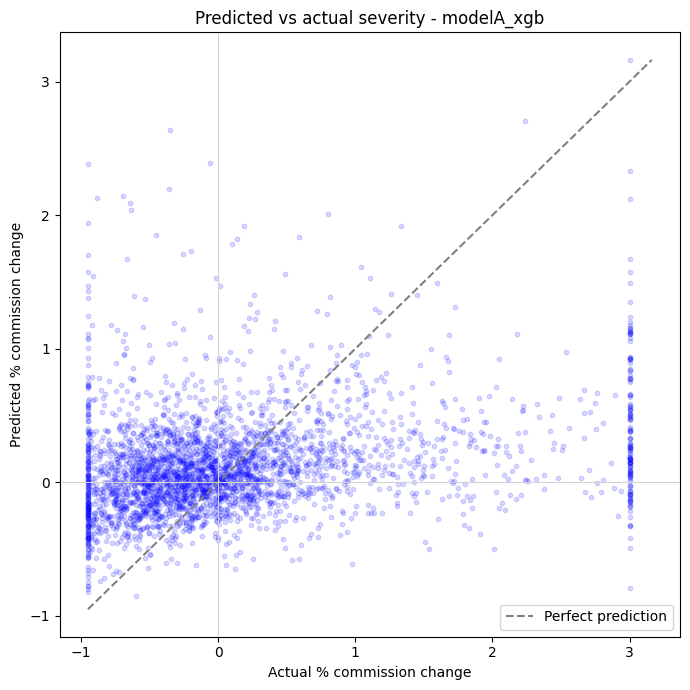

In [11]:
best_model_a_name = max(model_a_store, key=lambda n: spearmanr(
    y_test, model_a_store[n].predict(Xte))[0])
best_est = model_a_store[best_model_a_name]
pred_best = best_est.predict(Xte)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred_best, alpha=0.15, s=10, color="blue")
lims = [min(y_test.min(), pred_best.min()), max(y_test.max(), pred_best.max())]
ax.plot(lims, lims, "--", color="grey", label="Perfect prediction")
ax.axhline(0, color="lightgrey", linewidth=0.8)
ax.axvline(0, color="lightgrey", linewidth=0.8)
ax.set_xlabel("Actual % commission change")
ax.set_ylabel("Predicted % commission change")
ax.set_title(f"Predicted vs actual severity - modelA_{best_model_a_name}")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / f"severity_scatter_modelA_{best_model_a_name}.png", dpi=150)
plt.show()


## 11. Comparison with the band-level severity gradient
I next compare individual severity predictions with realised severity after clients are grouped by classification risk score. The purpose is to see whether aggregation produces a more stable relationship than attempting to predict each client's exact percentage change.

In [12]:
print("===Individual predictions vs risk-band severity===")

risk_clf = RandomForestClassifier(**rf_clf_params)
risk_clf.fit(Xtr, train_df[TARGET].values)
risk_score_test = risk_clf.predict_proba(Xte)[:, 1]

band_df = pd.DataFrame({
    "risk_score": risk_score_test,
    "actual_severity": y_test,
    "predicted_severity_individual": pred_best,
})
bins = np.arange(0, 1.01, 0.10)
labels = [f"{int(b*100)}-{int((b+0.10)*100)}%" for b in bins[:-1]]
band_df["band"] = pd.cut(band_df["risk_score"], bins=bins, labels=labels, include_lowest=True)

band_compare = band_df.groupby("band", observed=True).agg(
    n=("actual_severity", "count"),
    mean_actual_severity=("actual_severity", "mean"),
    mean_individual_prediction=("predicted_severity_individual", "mean"),
    std_individual_prediction=("predicted_severity_individual", "std"),
).reset_index()
print(band_compare.round(4).to_string(index=False))
band_compare.to_csv(OUT_DIR / "band_level_vs_individual_severity.csv", index=False)



===Individual predictions vs risk-band severity===
  band   n  mean_actual_severity  mean_individual_prediction  std_individual_prediction
20-30% 110                0.4406                      0.6481                     0.5089
30-40% 571                0.4288                      0.4107                     0.3935
40-50% 913                0.2184                      0.2184                     0.2947
50-60% 726                0.0437                      0.0694                     0.2794
60-70% 621               -0.0982                     -0.1236                     0.2091
70-80% 228               -0.3425                     -0.3251                     0.1639
80-90%   5               -0.7521                     -0.5481                     0.1908


The average realised outcome changes consistently as classification risk increases. Lower-risk bands grow on average, the 50–60% band is close to flat, and the higher-risk bands decline increasingly sharply. The 80–90% group contains only five clients, so I would not place much weight on its -75.2% average by itself.

### Individual-level relationship

The next chart shows the same relationship at client level. This makes it easier to see how much variation sits underneath the band averages.

- Actual growth above +100% is capped on the chart only so that the main part of the distribution remains readable. The uncapped values are still used for the reported correlations.
- Decline does not need the same display adjustment because percentage loss is naturally bounded at -100%.

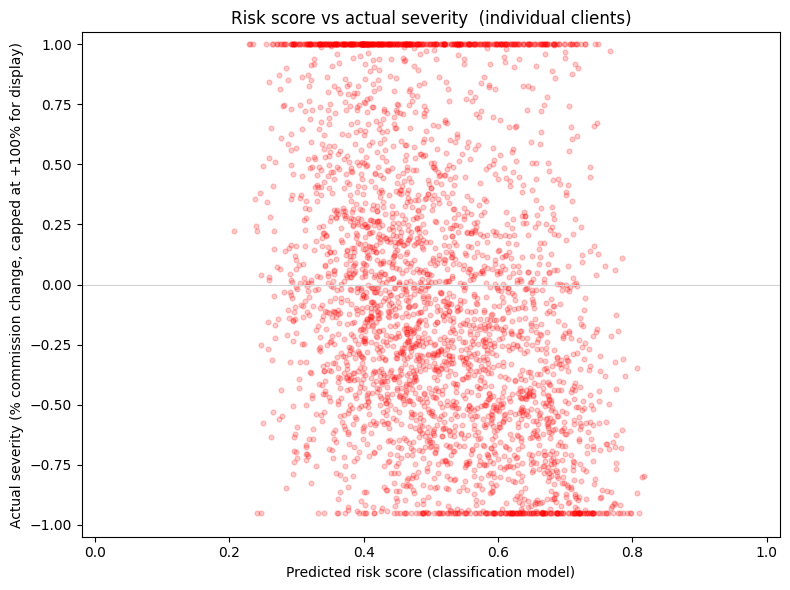


Risk score vs actual severity (individual clients, raw - not band-averaged):
  Pearson r  = -0.2472  (p = 2.19e-45)
  Spearman r = -0.3334  (p = 2.94e-83)


In [13]:
# risk score vs actual severity



GROWTH_DISPLAY_CAP = 1.0  # +100%, display only - not winsorising
n_above_cap = (y_test > GROWTH_DISPLAY_CAP).sum()
y_test_display = np.clip(y_test, -1.0, GROWTH_DISPLAY_CAP)

pearson_r, pearson_p = pearsonr(risk_score_test, y_test)
spearman_r_raw, spearman_p = spearmanr(risk_score_test, y_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(risk_score_test, y_test_display, alpha=0.2, s=12, color="red")
ax.axhline(0, color="lightgrey", linewidth=0.8)
ax.set_xlabel("Predicted risk score (classification model)")
ax.set_ylabel("Actual severity (% commission change, capped at +100% for display)")
ax.set_title("Risk score vs actual severity  (individual clients)")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-1.05, GROWTH_DISPLAY_CAP + 0.05)


fig.tight_layout()
fig.savefig(OUT_DIR / "risk_score_vs_severity_scatter.png", dpi=150)
plt.show()

print(f"\nRisk score vs actual severity (individual clients, raw - not band-averaged):")
print(f"  Pearson r  = {pearson_r:.4f}  (p = {pearson_p:.2e})")
print(f"  Spearman r = {spearman_r_raw:.4f}  (p = {spearman_p:.2e})")



The relationship is statistically clear but not particularly strong at individual-client level. Spearman correlation of -0.333 means higher risk is associated with worse realised outcomes, but the wide scatter shows why I would not use the risk score to infer an exact decline percentage for one client.

### Individual noise and band-level signal

The individual observations show a slight relationship between higher risk and worse severity, but there is wide variation between clients. When the same clients are averaged into risk bands, the relationship becomes much clearer.

The individual predictions are therefore too noisy to use confidently as exact client-level decline forecasts, while the band averages provide a more stable view of outcomes for groups of clients with similar risk.

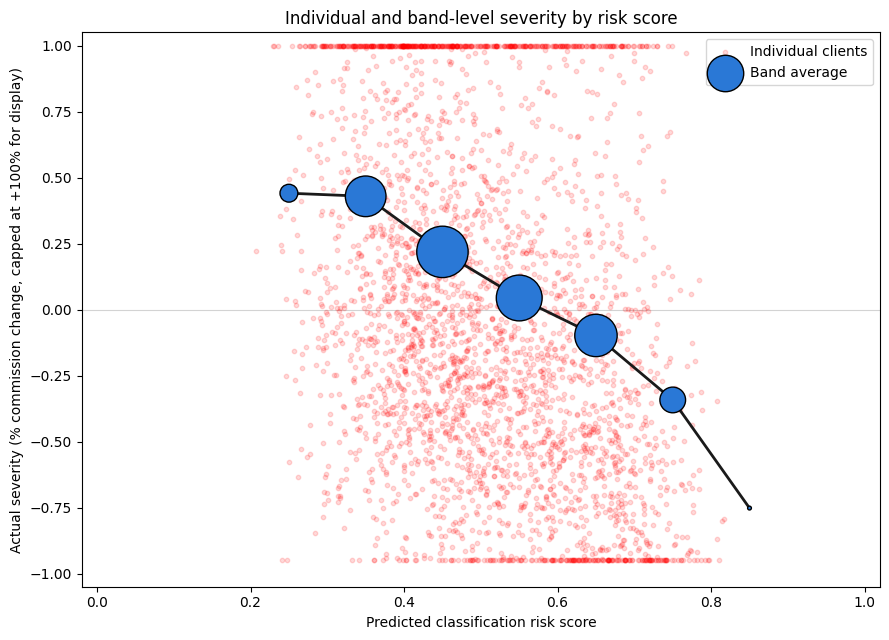

In [14]:
band_midpoints = {labels[i]: (bins[i] + bins[i+1]) / 2 for i in range(len(bins) - 1)}
band_compare["risk_band_midpoint"] = band_compare["band"].map(band_midpoints)

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(risk_score_test, y_test_display, alpha=0.15, s=10, color="red",
           label="Individual clients", zorder=1)
ax.plot(band_compare["risk_band_midpoint"], band_compare["mean_actual_severity"],
        color="#1a1a1a", linewidth=2, zorder=3)
ax.scatter(band_compare["risk_band_midpoint"], band_compare["mean_actual_severity"],
           s=band_compare["n"] * 1.5, color="#2a78d6", edgecolor="black", linewidth=1,
           label="Band average", zorder=4)
ax.axhline(0, color="lightgrey", linewidth=0.8, zorder=0)
ax.set_xlabel("Predicted classification risk score")
ax.set_ylabel("Actual severity (% commission change, capped at +100% for display)")
ax.set_title("Individual and band-level severity by risk score")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-1.05, GROWTH_DISPLAY_CAP + 0.05)
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUT_DIR / "individual_noise_vs_band_signal.png", dpi=150)
plt.show()

band_corr = band_compare[["risk_band_midpoint", "mean_actual_severity"]].corr().iloc[0, 1]


## 12. Permutation test on the band-level pattern

The band averages show a strong relationship between risk and realised severity, but there are only seven populated bands - so the question worth asking is whether that pattern could just be luck, seven points landing roughly in line by chance, rather than a genuine result. I use a permutation test as an additional check on this.

Severity values are shuffled across clients 2,000 times while keeping the original risk scores fixed. Each shuffle breaks any real link between risk and severity, so it shows what the band-level correlation would look like if the relationship were pure chance. I recalculate the band averages and correlation for each shuffle, and compare that against the correlation actually observed in the real, unshuffled data.

In [15]:
N_PERM = 2000
rng = np.random.default_rng(RANDOM_STATE)
observed_abs_band_corr = abs(band_corr)

perm_corrs = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled_severity = rng.permutation(y_test)
    perm_df = pd.DataFrame({"risk_score": risk_score_test, "severity": shuffled_severity})
    perm_df["band"] = pd.cut(perm_df["risk_score"], bins=bins, labels=labels, include_lowest=True)
    perm_means = perm_df.groupby("band", observed=True)["severity"].mean()
    perm_x = perm_means.index.map(band_midpoints).astype(float)
    if len(perm_means) >= 3 and perm_means.std() > 0:
        r = np.corrcoef(perm_x, perm_means.values)[0, 1]
        perm_corrs[i] = abs(r) if np.isfinite(r) else 0.0
    else:
        perm_corrs[i] = 0.0

n_as_extreme = int((perm_corrs >= observed_abs_band_corr).sum())
perm_p = n_as_extreme / N_PERM

print("Band-level permutation test")
print(f"Observed band-level |correlation| = {observed_abs_band_corr:.4f}")
print(f"Across {N_PERM:,} random shuffles of severity vs risk score (true pairing broken):")
print(f"  Mean |correlation|  = {perm_corrs.mean():.4f}")
print(f"  95th percentile= {np.quantile(perm_corrs, 0.95):.4f}")
print(f"  Shuffles at least as strong as observed     = {n_as_extreme:,} / {N_PERM:,}  "
      f"(p = {perm_p:.4f}{' (< 1 in ' + str(N_PERM) + ')' if n_as_extreme == 0 else ''})")


Band-level permutation test
Observed band-level |correlation| = 0.9711
Across 2,000 random shuffles of severity vs risk score (true pairing broken):
  Mean |correlation|  = 0.5287
  95th percentile= 0.7998
  Shuffles at least as strong as observed     = 1 / 2,000  (p = 0.0005)


Only one of the 2,000 shuffled datasets produced a band-level correlation at least as strong as the observed pattern. This supports the conclusion that the ordered band relationship is unlikely to be the result of random allocation alone. It does not make individual severity predictions precise; it supports using the relationship at an aggregated level.

## 13. GP-tuned threshold sensitivity

Model B above uses the classifier's default 0.5 threshold. As an additional sensitivity check, I refit the Random Forest classifier and use a GP-weighted F1 threshold before estimating severity within the flagged population.

This is not intended to reproduce Notebook 02's OOF threshold exactly. It tests the narrower question of whether severity becomes more useful when the analysis is restricted to clients identified as higher risk.

The final evaluation remains on the held-out test population.

In [17]:
print("GP-tuned threshold severity sensitivity")


def tune_gp_threshold(y_true, y_proba, weights):
    thresholds = np.arange(0.20, 0.81, 0.01)
    scores = [f1_score(y_true, (y_proba >= th).astype(int), sample_weight=weights, zero_division=0)
              for th in thresholds]
    return thresholds[int(np.argmax(scores))]

def build_weights(values):
    v = np.clip(np.asarray(values, dtype=float), 0, None)
    return v / v.mean()

gp_tuned_clf = RandomForestClassifier(**rf_clf_params)
gp_tuned_clf.fit(Xtr, train_df[TARGET].values)

w_eval_train = build_weights(train_df["core_gp_l12m"].values)
w_eval_test  = build_weights(test_df["core_gp_l12m"].values)

proba_train = gp_tuned_clf.predict_proba(Xtr)[:, 1]
proba_test  = gp_tuned_clf.predict_proba(Xte)[:, 1]
gp_threshold = tune_gp_threshold(train_df[TARGET].values, proba_train, w_eval_train)

train_flagged_gp = proba_train >= gp_threshold
test_flagged_gp  = proba_test >= gp_threshold

print(f"  GP-tuned threshold: {gp_threshold:.2f}")
print(f"  Flags {train_flagged_gp.mean():.1%} of train, {test_flagged_gp.mean():.1%} of test "
      f"as at-risk (compare to Model B's default-threshold Stage 1: "
      f"{train_flagged.mean():.1%} / {test_flagged.mean():.1%})")

severity_on_flagged = RandomForestRegressor(**rf_reg_params)
severity_on_flagged.fit(Xtr[train_flagged_gp], y_train[train_flagged_gp])

if test_flagged_gp.sum() > 0:
    y_test_flagged = y_test[test_flagged_gp]
    pred_flagged = severity_on_flagged.predict(Xte[test_flagged_gp])
    commission_flagged = commission_test[test_flagged_gp]

    row_flagged = evaluate_severity(y_test_flagged, pred_flagged, commission_flagged,
                                    "severity_on_gp_tuned_flagged_population")
    print(f"\n  Evaluated on {test_flagged_gp.sum():,} flagged test clients:")
    print(f"    directional_accuracy = {row_flagged['directional_accuracy']:.3f}")
    print(f"    actual_loss_capture  = {row_flagged['actual_loss_capture']:.3f}")
    print(f"    spearman             = {row_flagged['spearman_rank_correlation']:.3f}")
    print(f"    mae "
          f"= {row_flagged['mae_whole_book']:.3f}")

    actual_decline_rate_in_flagged = (y_test_flagged < 0).mean()
    print(f"\n  Actual decline rate within the flagged population: "
          f"{actual_decline_rate_in_flagged:.1%}")
    print(f"  Mean actual severity within the flagged population: {y_test_flagged.mean():.3f}")
    print(f"  Mean predicted severity for the flagged population: {pred_flagged.mean():.3f}")


    pd.DataFrame([row_flagged]).round(4).to_csv(
        OUT_DIR / "severity_on_gp_tuned_flagged_population.csv", index=False)
else:
    print("  No test clients flagged at this threshold - cannot evaluate.")



GP-tuned threshold severity sensitivity
  GP-tuned threshold: 0.42
  Flags 70.8% of train, 72.6% of test as at-risk (compare to Model B's default-threshold Stage 1: 51.2% / 49.8%)

  Evaluated on 2,303 flagged test clients:
    directional_accuracy = 0.592
    actual_loss_capture  = 0.453
    spearman             = 0.079
    mae = 0.634

  Actual decline rate within the flagged population: 62.8%
  Mean actual severity within the flagged population: 0.014
  Mean predicted severity for the flagged population: -0.075
